<a href="https://colab.research.google.com/github/syltaer-utp/Project-S100/blob/main/S100_Equipo2_ParteI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# S100 — Parte I: Exploración preliminar
## Gasto en salud y esperanza de vida (América + Europa, 2000–2024)

**Equipo 2** · Universidad Tecnológica de Panamá — Maestría en Analítica de Datos  
Cuaderno que acompaña el white paper `S100_Equipo2_ParteI.pdf`.

## 1. Librerías y configuración


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (9, 4.5)
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["figure.dpi"] = 100


## 2. Carga del conjunto de datos original

El archivo `health_panel.csv` es un panel país-año construido a partir de fuentes oficiales (World Bank, WHO y OECD).  
Contiene indicadores de esperanza de vida, gasto en salud, mortalidad, PIB y recursos sanitarios desde 1960 hasta 2024.

In [16]:
DATA_PATH = "health_panel.csv"
df = pd.read_csv(DATA_PATH, low_memory=False)

print(f"Shape: {df.shape[0]:,} filas × {df.shape[1]} columnas")
print(f"Años: {df['year'].min()} – {df['year'].max()}")
print(f"Países / entidades: {df['country_name'].nunique()}")
print(f"\nColumnas:{df.columns.tolist()}")
print("\n")
df.info()


Shape: 17,210 filas × 32 columnas
Años: 1960 – 2024
Países / entidades: 265

Columnas:['country_code', 'country_name', 'year', 'life_expectancy_total', 'life_expectancy_female', 'life_expectancy_male', 'life_expectancy_gender_gap', 'le_total_yoy_change', 'region', 'income_group', 'iso2_code', 'health_spend_pct_gdp', 'health_spend_per_capita_usd', 'spend_pct_gdp_yoy_change', 'spend_per_capita_yoy_pct', 'hospital_beds_per_1000', 'physicians_per_1000', 'nurses_midwives_per_1000', 'total_health_workers_per_1000', 'infant_mortality_per_1000', 'under5_mortality_per_1000', 'maternal_mortality_per_100k', 'infant_mortality_yoy_change', 'under5_mortality_yoy_change', 'gdp_per_capita_usd', 'population_total', 'log_gdp_per_capita', 'gdp_per_capita_yoy_pct', 'le_per_gdp_point', 'le_per_1k_spend', 'le_spend_residual', 'efficiency_score']


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17210 entries, 0 to 17209
Data columns (total 32 columns):
 #   Column                         Non-Null Count  D

### 2.1 Valores faltantes (dataset completo)

In [17]:
missing_full = (df.isnull().mean() * 100).sort_values(ascending=False)
print("% faltantes — dataset completo")
print(missing_full.round(1).to_string())
total = df.shape[0] * df.shape[1]
print(f"\nFaltantes globales: {df.isnull().sum().sum():,} / {total:,} celdas ({100 * df.isnull().sum().sum() / total:.1f}%)")


% faltantes — dataset completo
income_group                     100.0
iso2_code                        100.0
region                           100.0
nurses_midwives_per_1000          79.4
spend_per_capita_yoy_pct          68.2
spend_pct_gdp_yoy_change          68.2
physicians_per_1000               67.9
health_spend_per_capita_usd       66.8
le_spend_residual                 66.8
efficiency_score                  66.8
le_per_1k_spend                   66.8
le_per_gdp_point                  66.8
health_spend_pct_gdp              66.8
hospital_beds_per_1000            65.9
total_health_workers_per_1000     65.9
maternal_mortality_per_100k       45.2
infant_mortality_yoy_change       22.9
under5_mortality_yoy_change       22.7
infant_mortality_per_1000         21.5
under5_mortality_per_1000         21.3
gdp_per_capita_yoy_pct            16.5
gdp_per_capita_usd                15.4
log_gdp_per_capita                15.4
le_total_yoy_change                1.7
country_code                     

### 2.2 Estadísticos descriptivos (dataset completo)

Media, mediana, desviación y rango de la variable objetivo y de tres predictoras.


In [18]:
desc_vars = [
    "life_expectancy_total",
    "health_spend_per_capita_usd",
    "gdp_per_capita_usd",
    "infant_mortality_per_1000"
]
desc_full = df[desc_vars].describe().T
desc_full["median"] = df[desc_vars].median()
desc_full["missing_pct"] = df[desc_vars].isnull().mean() * 100
print(desc_full[["count", "mean", "median", "std", "min", "max", "missing_pct"]].round(2).to_string())


                               count     mean   median       std    min        max  missing_pct
life_expectancy_total        17191.0    64.87    67.25     11.08  10.99      86.50         0.11
health_spend_per_capita_usd   5713.0   973.11   253.98   1758.59   4.18   13473.19        66.80
gdp_per_capita_usd           14561.0  8701.89  1938.81  17595.34  11.80  288001.43        15.39
infant_mortality_per_1000    13510.0    47.71    33.70     43.84   1.20     484.00        21.50


En el panel completo (1960–2024) la esperanza de vida media ( ~65 años) está por debajo de la mediana ( ~67): hay cola izquierda (años con LE muy baja). Gasto y PIB muestran media mucho mayor que la mediana (cola derecha). El gasto en salud falta en ~67 % de las filas porque la serie es más reciente.


## 3. Subset de trabajo: América + Europa, años ≥ 2000

Se excluyen agregados regionales y se limita el período a 2000–2024 para trabajar con datos más recientes y cobertura aceptable de gasto en salud.


In [19]:
americas = [
    "Antigua and Barbuda", "Argentina", "Bahamas, The", "Barbados", "Belize",
    "Bolivia", "Brazil", "Canada", "Chile", "Colombia", "Costa Rica", "Cuba",
    "Dominica", "Dominican Republic", "Ecuador", "El Salvador", "Grenada",
    "Guatemala", "Guyana", "Haiti", "Honduras", "Jamaica", "Mexico",
    "Nicaragua", "Panama", "Paraguay", "Peru", "St. Kitts and Nevis",
    "St. Lucia", "St. Vincent and the Grenadines", "Suriname",
    "Trinidad and Tobago", "United States", "Uruguay", "Venezuela, RB"
]
europe = [
    "Albania", "Austria", "Belarus", "Belgium", "Bosnia and Herzegovina",
    "Bulgaria", "Croatia", "Cyprus", "Czechia", "Denmark", "Estonia",
    "Finland", "France", "Germany", "Greece", "Hungary", "Iceland",
    "Ireland", "Italy", "Latvia", "Lithuania", "Luxembourg", "Malta",
    "Moldova", "Montenegro", "Netherlands", "North Macedonia", "Norway",
    "Poland", "Portugal", "Romania", "Russian Federation", "Serbia",
    "Slovak Republic", "Slovenia", "Spain", "Sweden", "Switzerland",
    "Ukraine", "United Kingdom"
]

df_ae = df[df["country_name"].isin(americas + europe)].copy()
df_ae["continent"] = np.where(df_ae["country_name"].isin(americas), "Americas", "Europe")
df_subset = df_ae[df_ae["year"] >= 2000].copy()

print(f"Shape subset: {df_subset.shape[0]:,} filas × {df_subset.shape[1]} columnas")
print(f"Años: {df_subset['year'].min()} – {df_subset['year'].max()}")
print(f"Países: {df_subset['country_name'].nunique()} "
      f"(América {df_subset.loc[df_subset.continent=='Americas','country_name'].nunique()}, "
      f"Europa {df_subset.loc[df_subset.continent=='Europe','country_name'].nunique()})")


Shape subset: 1,875 filas × 33 columnas
Años: 2000 – 2024
Países: 75 (América 35, Europa 40)


### 3.1 Valores faltantes (subset)


In [20]:
missing_sub = (df_subset.isnull().mean() * 100).sort_values(ascending=False)
print("% faltantes — subset")
print(missing_sub.round(1).to_string())
total_s = df_subset.shape[0] * df_subset.shape[1]
print(f"\nFaltantes globales subset: {df_subset.isnull().sum().sum():,} / {total_s:,} ({100 * df_subset.isnull().sum().sum() / total_s:.1f}%)")


% faltantes — subset
region                           100.0
iso2_code                        100.0
income_group                     100.0
physicians_per_1000               32.6
nurses_midwives_per_1000          29.7
total_health_workers_per_1000     25.4
hospital_beds_per_1000            21.3
spend_pct_gdp_yoy_change           8.6
spend_per_capita_yoy_pct           8.6
health_spend_per_capita_usd        4.7
efficiency_score                   4.7
le_spend_residual                  4.7
le_per_1k_spend                    4.7
le_per_gdp_point                   4.6
health_spend_pct_gdp               4.6
maternal_mortality_per_100k        4.0
log_gdp_per_capita                 0.2
gdp_per_capita_usd                 0.2
country_code                       0.0
life_expectancy_total              0.0
country_name                       0.0
life_expectancy_gender_gap         0.0
life_expectancy_male               0.0
le_total_yoy_change                0.0
year                               0.0
life

`region`, `income_group` e `iso2_code` están vacías al 100 % (no se usan). Entre variables de análisis, los faltantes más altos están en recursos humanos (médicos ~33 %, enfermeras ~30 %, camas ~21 %). Gasto en salud y esperanza de vida tienen menos del 5 % de faltantes.


### 3.2 Estadísticos descriptivos del subset (Tabla 1 del white paper)


In [21]:
desc = df_subset[desc_vars].describe().T[["mean", "50%", "min", "max"]]
desc = desc.rename(columns={"50%": "median"})
desc["std"] = df_subset[desc_vars].std()
desc["IQR"] = df_subset[desc_vars].quantile(0.75) - df_subset[desc_vars].quantile(0.25)
desc["missing_pct"] = df_subset[desc_vars].isnull().mean() * 100
print(desc[["mean", "median", "std", "min", "max", "IQR", "missing_pct"]].round(2).to_string())


                                 mean    median       std     min        max       IQR  missing_pct
life_expectancy_total           75.51     75.54      4.74   45.58      84.41      7.17         0.00
health_spend_per_capita_usd   1770.71    779.39   2195.96   18.61   13473.19   2010.19         4.75
gdp_per_capita_usd           20386.59  11556.30  22212.85  440.54  137781.68  22503.44         0.21
infant_mortality_per_1000       11.00      7.70      9.69    1.50      79.30     12.00         0.00


- **Esperanza de vida:** media ≈ mediana (75,5 años) → distribución relativamente simétrica; desviación ~4,7 años.
- **Gasto en salud per cápita:** media (1 771 USD) más del doble de la mediana (779 USD) → cola derecha fuerte; la mediana describe mejor al país típico.
- **PIB per cápita:** mismo patrón de cola derecha.
- **Mortalidad infantil:** media 11 > mediana 7,7 → cola derecha (países con mortalidad elevada).


## 4. Forma de la distribución

### 4.1 Figura 1 — Histograma de la variable objetivo


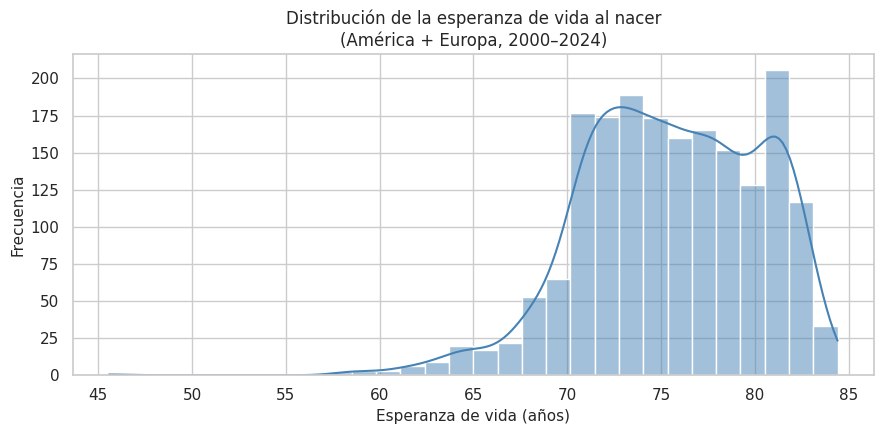

In [22]:
fig, ax = plt.subplots()
sns.histplot(data=df_subset, x="life_expectancy_total", bins=30, kde=True, color="steelblue", ax=ax)
ax.set_title("Distribución de la esperanza de vida al nacer\n(América + Europa, 2000–2024)")
ax.set_xlabel("Esperanza de vida (años)")
ax.set_ylabel("Frecuencia")
plt.tight_layout()
plt.savefig("figura1_histograma_le.png", dpi=150, bbox_inches="tight")
plt.show()


La masa se concentra entre 70 y 82 años, con una cola izquierda (países/años de menor LE). Eso implica heterogeneidad entre países y justifica controlar por continente y por nivel de ingreso en el modelado.


### 4.2 Histogramas de predictoras y boxplots por continente


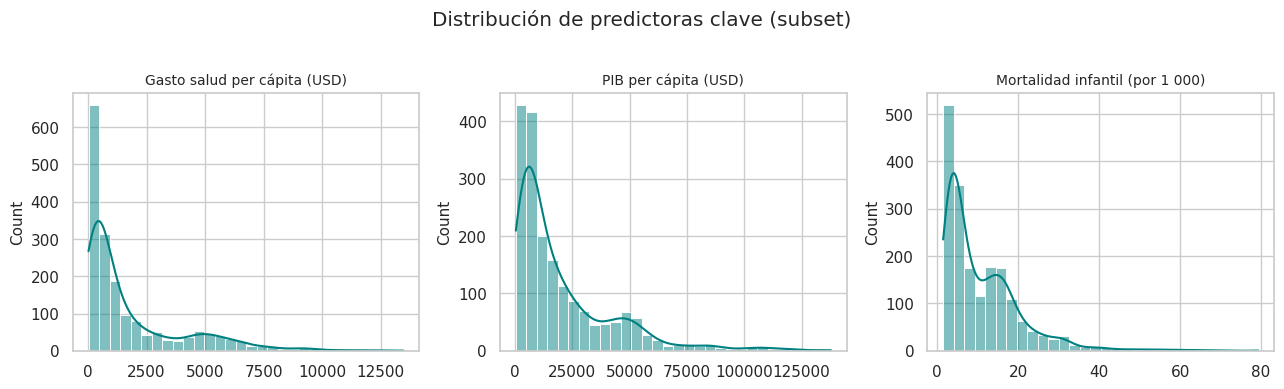

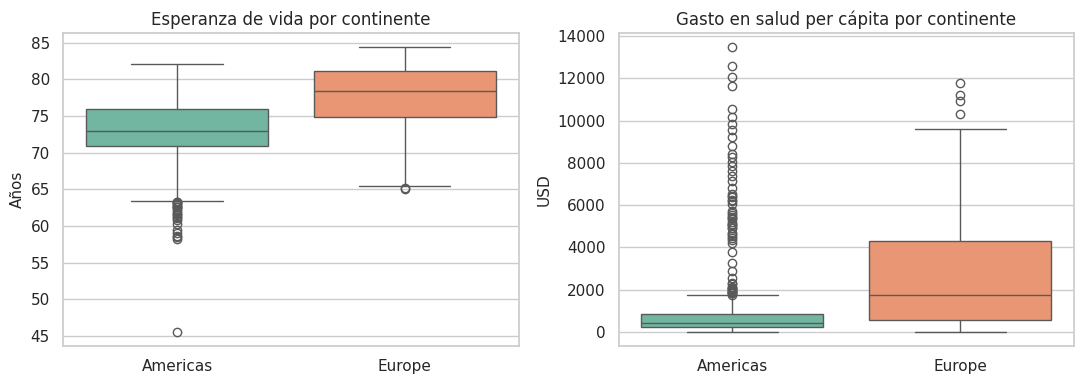

          life_expectancy_total        health_spend_per_capita_usd         gdp_per_capita_usd          infant_mortality_per_1000       
                           mean median                        mean  median               mean   median                      mean median
continent                                                                                                                              
Americas                   73.0   72.9                       868.8   405.0            10759.1   6739.4                      17.6   16.0
Europe                     77.7   78.4                      2539.8  1761.1            28772.1  21811.5                       5.2    3.9


In [23]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
for ax, col, label in zip(
    axes,
    ["health_spend_per_capita_usd", "gdp_per_capita_usd", "infant_mortality_per_1000"],
    ["Gasto salud per cápita (USD)", "PIB per cápita (USD)", "Mortalidad infantil (por 1 000)"]
):
    sns.histplot(data=df_subset, x=col, bins=30, kde=True, color="teal", ax=ax)
    ax.set_title(label, fontsize=10)
    ax.set_xlabel("")
plt.suptitle("Distribución de predictoras clave (subset)", y=1.02)
plt.tight_layout()
plt.savefig("fig_hist_predictoras.png", dpi=150, bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.boxplot(data=df_subset, x="continent", y="life_expectancy_total", hue="continent",
            ax=axes[0], palette="Set2", legend=False)
axes[0].set_title("Esperanza de vida por continente")
axes[0].set_xlabel("")
axes[0].set_ylabel("Años")
sns.boxplot(data=df_subset, x="continent", y="health_spend_per_capita_usd", hue="continent",
            ax=axes[1], palette="Set2", legend=False)
axes[1].set_title("Gasto en salud per cápita por continente")
axes[1].set_xlabel("")
axes[1].set_ylabel("USD")
plt.tight_layout()
plt.savefig("fig_box_continent.png", dpi=150, bbox_inches="tight")
plt.show()

print(df_subset.groupby("continent")[desc_vars].agg(["mean", "median"]).round(1).to_string())


Europa muestra mayor esperanza de vida (media ~77,7 vs ~73,0 en América) y mayor gasto en salud. Las cajas confirman mayor dispersión del gasto en Europa (valores extremos altos).


## 5. Relaciones entre variables (hipótesis)

Correlación de Pearson y dispersión gasto ↔ esperanza de vida.  
*Correlación no implica causalidad* (Como se menciona en la Clase 3); sirve para orientar el modelado.


                             life_expectancy_total  health_spend_per_capita_usd  gdp_per_capita_usd  infant_mortality_per_1000
life_expectancy_total                        1.000                        0.685               0.687                     -0.807
health_spend_per_capita_usd                  0.685                        1.000               0.937                     -0.491
gdp_per_capita_usd                           0.687                        0.937               1.000                     -0.498
infant_mortality_per_1000                   -0.807                       -0.491              -0.498                      1.000


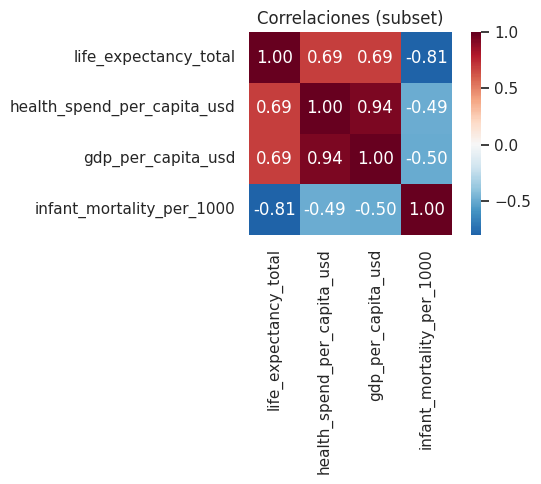

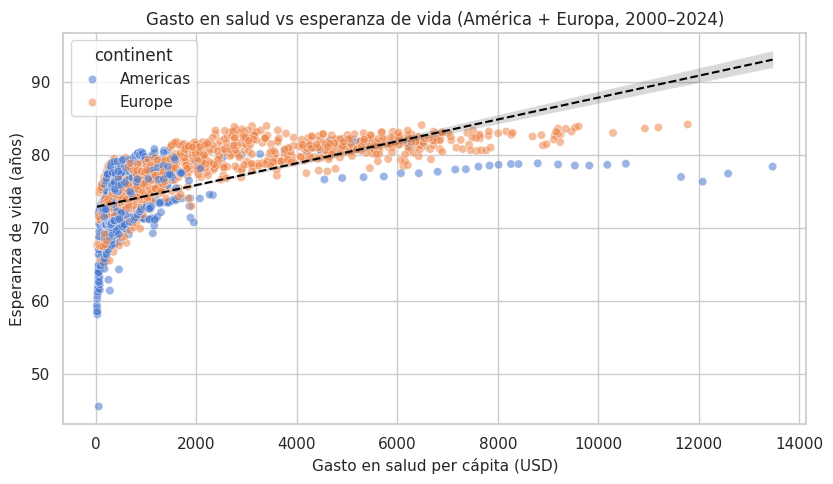

In [24]:
corr = df_subset[desc_vars].corr()
print(corr.round(3).to_string())

fig, ax = plt.subplots(figsize=(6.5, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, square=True, ax=ax)
ax.set_title("Correlaciones (subset)")
plt.tight_layout()
plt.savefig("fig_corr_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(8.5, 5))
sns.scatterplot(
    data=df_subset.dropna(subset=["health_spend_per_capita_usd", "life_expectancy_total"]),
    x="health_spend_per_capita_usd", y="life_expectancy_total",
    hue="continent", alpha=0.55, ax=ax
)
sns.regplot(
    data=df_subset.dropna(subset=["health_spend_per_capita_usd", "life_expectancy_total"]),
    x="health_spend_per_capita_usd", y="life_expectancy_total",
    scatter=False, color="black",
    line_kws={"linewidth": 1.5, "linestyle": "--"}, ax=ax
)
ax.set_xlabel("Gasto en salud per cápita (USD)")
ax.set_ylabel("Esperanza de vida (años)")
ax.set_title("Gasto en salud vs esperanza de vida (América + Europa, 2000–2024)")
plt.tight_layout()
plt.savefig("fig_scatter_spend_le.png", dpi=150, bbox_inches="tight")
plt.show()


Resultados clave de correlación:
- Gasto salud ↔ LE: **r ≈ 0,69** (positiva, alineada con la hipótesis)
- PIB ↔ LE: **r ≈ 0,69**
- Mortalidad infantil ↔ LE: **r ≈ −0,81** (negativa fuerte)
- Gasto ↔ PIB: **r ≈ 0,94** (colinealidad alta → en el modelado habrá que controlar o elegir con cuidado)

La nube de puntos muestra la tendencia positiva esperada; Europa concentra más observaciones de alto gasto y alta LE.
